# Interval Rep Charts and Values

This notebook visualizes interval-rep quality for:
1. Rep power consistency
2. HR recovery between reps
3. Cardiac drift across reps
4. Peak HR progression
5. Rep pace consistency

You can analyze one specific run or all interval runs together.

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

cwd = Path.cwd()
candidate_report_dirs = [
    cwd / 'reports' / 'interval',
    cwd.parent / 'reports' / 'interval',
]

report_dir = next((p for p in candidate_report_dirs if (p / 'interval_level_dataset.csv').exists()), None)
if report_dir is None:
    raise FileNotFoundError(f'Could not find reports/interval from {cwd}')

interval_level_path = report_dir / 'interval_level_dataset.csv'
workout_level_path = report_dir / 'interval_workouts_dataset.csv'

interval_df = pd.read_csv(interval_level_path)
workout_df = pd.read_csv(workout_level_path) if workout_level_path.exists() else pd.DataFrame()

if 'date' in interval_df.columns:
    interval_df['date'] = pd.to_datetime(interval_df['date'], errors='coerce')
if not workout_df.empty and 'date' in workout_df.columns:
    workout_df['date'] = pd.to_datetime(workout_df['date'], errors='coerce')

interval_df = interval_df[interval_df['session_type'].str.lower().eq('interval')].copy()
if interval_df.empty:
    raise ValueError('No interval rows found in interval_level_dataset.csv')

print(f'Using report folder: {report_dir}')
print(f'Interval runs available: {interval_df["file"].nunique()}')

Using report folder: c:\Users\A717631\repo\theEagle\reports\interval
Interval runs available: 5


In [16]:
# Set to a specific filename to analyze one run, or keep None for all interval runs
# SELECTED_RUN = None
SELECTED_RUN = '2026-06-06_saturday_interval.fit'
# Example: SELECTED_RUN = '2026-05-26_tuesday_interval.fit'

available_runs = sorted(interval_df['file'].dropna().unique())
print('Available interval runs:')
for run_name in available_runs:
    print(' -', run_name)

if SELECTED_RUN is None:
    plot_df = interval_df.copy()
    mode_text = 'ALL interval runs'
else:
    # Try exact match first.
    plot_df = interval_df[interval_df['file'].eq(SELECTED_RUN)].copy()

    # Then try a case-insensitive match for convenience.
    if plot_df.empty:
        lower_map = {str(x).lower(): x for x in available_runs}
        matched = lower_map.get(str(SELECTED_RUN).lower())
        if matched is not None:
            SELECTED_RUN = matched
            plot_df = interval_df[interval_df['file'].eq(SELECTED_RUN)].copy()

    # If still missing, fall back to the latest available run.
    if plot_df.empty:
        if not available_runs:
            raise ValueError('No interval runs are available to plot.')
        fallback_run = available_runs[-1]
        print(f"\nWarning: SELECTED_RUN not found: {SELECTED_RUN}")
        print(f"Falling back to latest available run: {fallback_run}")
        SELECTED_RUN = fallback_run
        plot_df = interval_df[interval_df['file'].eq(SELECTED_RUN)].copy()

    mode_text = f'Single run -> {SELECTED_RUN}'

print(f'\nMode: {mode_text}')

plot_df = plot_df.sort_values(['file', 'interval_index'])
plot_df[['avg_power', 'hr_recovery_60s_bpm', 'avg_hr', 'max_hr', 'pace_min_per_km']] = plot_df[['avg_power', 'hr_recovery_60s_bpm', 'avg_hr', 'max_hr', 'pace_min_per_km']].apply(pd.to_numeric, errors='coerce')

display(plot_df.head(10))

Available interval runs:
 - 2026-04-28_tuesday_interval.fit
 - 2026-05-05_tuesday_interval.fit
 - 2026-05-12_tuesday_interval.fit
 - 2026-05-19_tuesday_interval.fit
 - 2026-05-26_tuesday_interval.fit

Falling back to latest available run: 2026-05-26_tuesday_interval.fit

Mode: Single run -> 2026-05-26_tuesday_interval.fit


,file,date,session_type,interval_index,interval_duration_s,recovery_duration_s,pace_min_per_km,avg_hr,max_hr,avg_power,cadence_spm,stride_length_m,ground_contact_time_ms,vertical_oscillation_mm,hr_response_lag_s,hr_recovery_60s_bpm
37,2026-05-26_tuesday_interval.fit,2026-05-26 05:24:20,interval,1,273.777,195.726,5.703856,152.0,162.0,303.0,164.0,1.0572,269.4,91.9,NaN,87.0
38,2026-05-26_tuesday_interval.fit,2026-05-26 05:24:20,interval,2,271.995,195.726,5.667007,157.0,169.0,317.0,160.0,1.0537,270.0,91.7,NaN,94.0
39,2026-05-26_tuesday_interval.fit,2026-05-26 05:24:20,interval,3,274.427,195.726,5.717553,159.0,170.0,298.0,164.0,1.0551,270.2,91.8,NaN,95.0
40,2026-05-26_tuesday_interval.fit,2026-05-26 05:24:20,interval,4,274.773,195.726,5.725409,161.0,170.0,320.0,164.0,1.0357,268.7,90.3,NaN,95.0
41,2026-05-26_tuesday_interval.fit,2026-05-26 05:24:20,interval,5,272.374,195.726,5.674725,162.0,169.0,300.0,166.0,1.0522,267.7,90.9,NaN,94.0
42,2026-05-26_tuesday_interval.fit,2026-05-26 05:24:20,interval,6,274.919,195.726,5.727377,163.0,171.0,324.0,164.0,1.0531,269.6,91.7,NaN,96.0
43,2026-05-26_tuesday_interval.fit,2026-05-26 05:24:20,interval,7,273.947,195.726,5.707763,165.0,174.0,298.0,166.0,1.0488,268.7,91.0,NaN,99.0
44,2026-05-26_tuesday_interval.fit,2026-05-26 05:24:20,interval,8,273.419,195.726,5.696058,165.0,176.0,325.0,166.0,1.0354,265.6,89.4,NaN,101.0
45,2026-05-26_tuesday_interval.fit,2026-05-26 05:24:20,interval,9,270.762,195.726,5.640158,167.0,176.0,306.0,168.0,1.0643,263.9,90.5,NaN,101.0
46,2026-05-26_tuesday_interval.fit,2026-05-26 05:24:20,interval,10,272.781,195.726,5.682464,166.0,176.0,324.0,166.0,1.0433,266.7,89.6,NaN,NaN


In [12]:
def cv_percent(series: pd.Series) -> float:
    x = pd.to_numeric(series, errors='coerce').dropna()
    if len(x) < 2 or float(x.mean()) == 0.0:
        return np.nan
    return float((x.std(ddof=1) / x.mean()) * 100.0)

def rep_drift(series: pd.Series) -> float:
    x = pd.to_numeric(series, errors='coerce').dropna()
    if len(x) < 2:
        return np.nan
    return float(x.iloc[-1] - x.iloc[0])

summary = (
    plot_df.groupby('file', as_index=False)
    .apply(
        lambda g: pd.Series({
            'rep_count': int(g['interval_index'].nunique()),
            'rep_power_consistency_cv_pct': cv_percent(g['avg_power']),
            'hr_recovery_between_reps_bpm_mean': float(pd.to_numeric(g['hr_recovery_60s_bpm'], errors='coerce').mean()),
            'cardiac_drift_across_reps_bpm': rep_drift(g['avg_hr']),
            'peak_hr_progression_bpm': rep_drift(g['max_hr']),
            'rep_pace_consistency_cv_pct': cv_percent(g['pace_min_per_km']),
        })
    )
    .reset_index(drop=True)
)

summary = summary.sort_values('file').reset_index(drop=True)
display(summary)

C:\Users\A717631\AppData\Local\Temp\ipykernel_2724\374476255.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,file,date,session_type,interval_index,interval_duration_s,recovery_duration_s,pace_min_per_km,avg_hr,max_hr,avg_power,cadence_spm,stride_length_m,ground_contact_time_ms,vertical_oscillation_mm,hr_response_lag_s,hr_recovery_60s_bpm


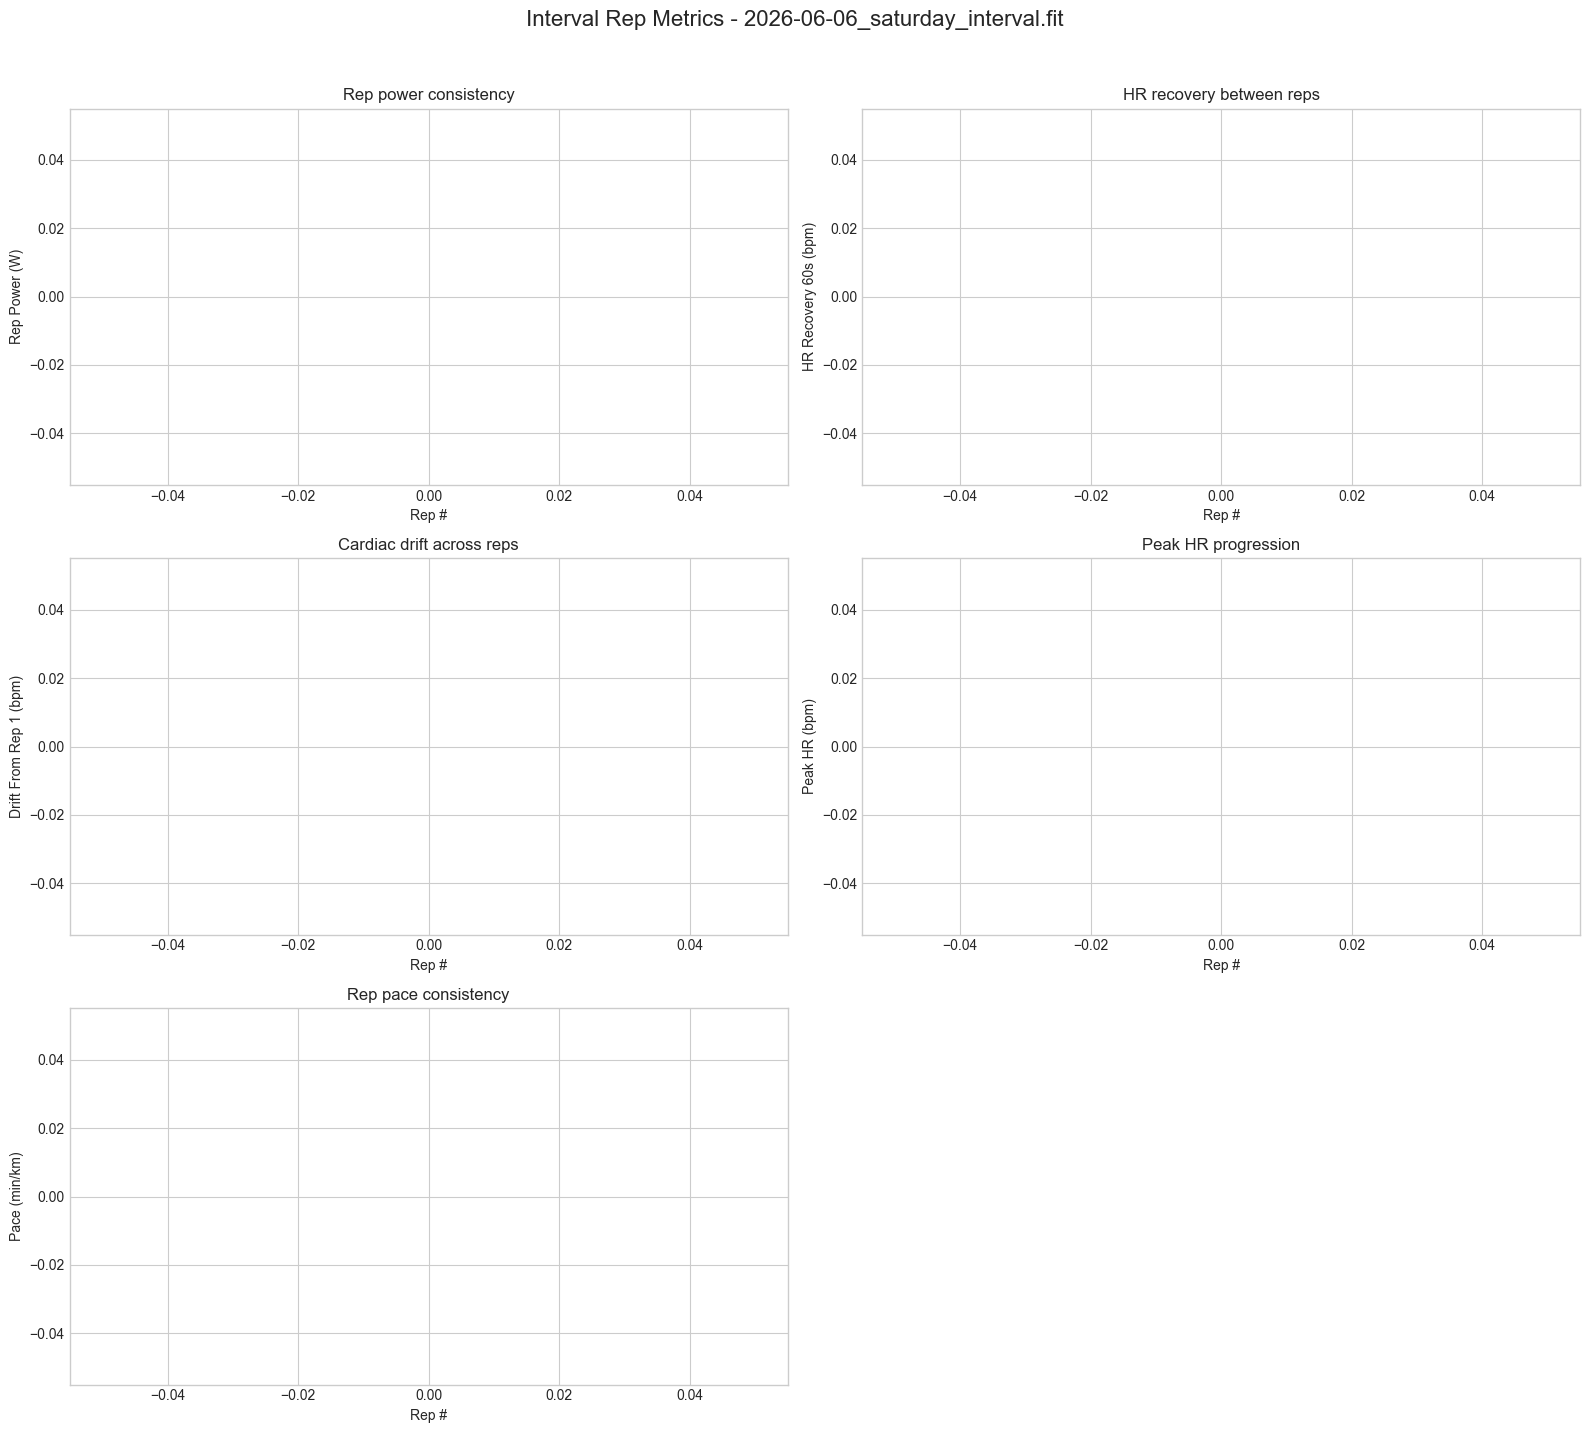

In [15]:
metrics = [
    ('avg_power', 'Rep Power (W)', 'Rep power consistency'),
    ('hr_recovery_60s_bpm', 'HR Recovery 60s (bpm)', 'HR recovery between reps'),
    ('avg_hr', 'Avg HR (bpm)', 'Cardiac drift across reps'),
    ('max_hr', 'Peak HR (bpm)', 'Peak HR progression'),
    ('pace_min_per_km', 'Pace (min/km)', 'Rep pace consistency'),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (col, y_label, title) in enumerate(metrics):
    ax = axes[i]

    if SELECTED_RUN is not None:
        g = plot_df.sort_values('interval_index')
        y = pd.to_numeric(g[col], errors='coerce')

        if col == 'avg_hr':
            y = y - y.iloc[0] if len(y.dropna()) else y
            y_label = 'Drift From Rep 1 (bpm)'

        ax.plot(g['interval_index'], y, marker='o', linewidth=2)
    else:
        for run_name, g in plot_df.groupby('file'):
            g = g.sort_values('interval_index')
            y = pd.to_numeric(g[col], errors='coerce')

            if col == 'avg_hr' and len(y.dropna()) > 0:
                y = y - y.iloc[0]
                y_label = 'Drift From Rep 1 (bpm)'

            ax.plot(g['interval_index'], y, marker='o', linewidth=1, alpha=0.35, color='gray')

        rep_agg = plot_df.groupby('interval_index')[col].agg(['mean', 'std']).reset_index()
        mean_y = pd.to_numeric(rep_agg['mean'], errors='coerce')

        if col == 'avg_hr' and len(mean_y.dropna()) > 0:
            mean_y = mean_y - mean_y.iloc[0]
            y_label = 'Drift From Rep 1 (bpm)'

        ax.plot(rep_agg['interval_index'], mean_y, marker='o', linewidth=2.5, color='tab:red', label='Mean')

        std_y = pd.to_numeric(rep_agg['std'], errors='coerce').fillna(0.0)
        ax.fill_between(
            rep_agg['interval_index'],
            mean_y - std_y,
            mean_y + std_y,
            color='tab:red',
            alpha=0.15,
            label='±1 SD'
        )
        ax.legend(loc='best')

    ax.set_title(title)
    ax.set_xlabel('Rep #')
    ax.set_ylabel(y_label)

axes[-1].axis('off')
mode_text = SELECTED_RUN if SELECTED_RUN is not None else 'All interval runs'
fig.suptitle(f'Interval Rep Metrics - {mode_text}', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()